In [1]:
!pip install Faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.5 MB/s eta 0:00:00


In [2]:
# STUDENT PERFORMANCE PREDICTION
# Synthetic Dataset Generation
import numpy as np
import pandas as pd
from faker import Faker

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)
Faker.seed(42)

fake = Faker()

N = 2000

print(f"Generating {N} synthetic student records...")

Generating 2000 synthetic student records...


# 1. Student Information


In [3]:
student_ids = [
    f"STU{10001 + i}"
    for i in range(N)
]

names = [
    fake.name()
    for _ in range(N)
]

ages = np.random.randint(
    17,
    25,
    size=N
)

genders = np.random.choice(
    ["Male", "Female", "Other"],
    size=N,
    p=[0.48, 0.48, 0.04]
)

# 2. Generate attendance

In [4]:
attendance = np.random.normal(
    loc=78,
    scale=10,
    size=N
)

attendance = np.clip(
    attendance,
    45,
    100
)

attendance = np.round(
    attendance,
    2
)

# 3. Generate study hours

In [5]:
study_hours = np.random.normal(
    loc=20,
    scale=6,
    size=N
)

study_hours = np.clip(
    study_hours,
    5,
    40
)

study_hours = np.round(
    study_hours,
    2
)

# 4. Generate previous grade

In [6]:
previous_grade = (
    25
    + 0.40 * attendance
    + 0.70 * study_hours
    + np.random.normal(0, 7, N)
)

previous_grade = np.clip(
    previous_grade,
    30,
    95
)

previous_grade = np.round(
    previous_grade,
    2
)

# 5. Generate assignment marks

In [7]:
assignment_marks = (
    0.55 * previous_grade
    + 0.90 * study_hours
    + 0.10 * attendance
    + np.random.normal(0, 6, N)
)

assignment_marks = np.clip(
    assignment_marks,
    25,
    100
)

assignment_marks = np.round(
    assignment_marks,
    2
)

# 6. Internal Assessment Marks


In [8]:
internal_marks = (
    0.35 * previous_grade
    + 0.20 * attendance
    + 0.35 * assignment_marks
    + np.random.normal(0, 5, N)
)

internal_marks = np.clip(
    internal_marks,
    25,
    100
)

internal_marks = np.round(
    internal_marks,
    2
)

# 7. Parental Support

In [9]:
parental_support = np.random.choice(
    ["Low", "Medium", "High"],
    size=N,
    p=[0.15, 0.55, 0.30]
)


# 8. Online Classes

In [10]:

online_classes = np.random.choice(
    ["Yes", "No"],
    size=N,
    p=[0.55, 0.45]
)


# 9. Extracurricular Activities

In [11]:
extracurricular = np.random.poisson(
    lam=1.5,
    size=N
)

extracurricular = np.clip(
    extracurricular,
    0,
    5
)

# 10. Final Examination Marks

In [12]:
# Convert categorical variables into numerical contributions

parental_effect = np.select(
    [
        parental_support == "Low",
        parental_support == "Medium",
        parental_support == "High"
    ],
    [
        -2,
        1,
        3
    ]
)

online_effect = np.where(
    online_classes == "Yes",
    1.5,
    0
)

extracurricular_effect = (
    np.minimum(extracurricular, 3) * 0.5
)

# Final examination score
final_exam_marks = (
    0.20 * previous_grade
    + 0.15 * attendance
    + 0.10 * study_hours
    + 0.20 * assignment_marks
    + 0.30 * internal_marks
    + parental_effect
    + online_effect
    + extracurricular_effect
    + np.random.normal(0, 6, N)
)

final_exam_marks = np.clip(
    final_exam_marks,
    0,
    100
)

final_exam_marks = np.round(
    final_exam_marks,
    2
)

# 11. Create Synthetic Dataset

In [13]:
df = pd.DataFrame({
    "StudentID": student_ids,
    "Name": names,
    "Age": ages,
    "Gender": genders,
    "AttendancePct": attendance,
    "StudyHoursPerWeek": study_hours,
    "PreviousGrade": previous_grade,
    "AssignmentMarks": assignment_marks,
    "InternalAssessmentMarks": internal_marks,
    "OnlineClasses": online_classes,
    "ExtracurricularActivities": extracurricular,
    "ParentalSupport": parental_support,
    "FinalExamMarks": final_exam_marks
})

print("Dataset generated successfully.")
print("Shape:", df.shape)

display(df.head(10))

Dataset generated successfully.
Shape: (2000, 13)


,StudentID,Name,Age,Gender,AttendancePct,StudyHoursPerWeek,PreviousGrade,AssignmentMarks,InternalAssessmentMarks,OnlineClasses,ExtracurricularActivities,ParentalSupport,FinalExamMarks
0,STU10001,Allison Hill,23,Male,88.60,7.78,85.35,53.76,67.11,Yes,1,Medium,68.20
1,STU10002,Noah Rhodes,20,Female,84.17,20.28,65.60,59.41,52.96,Yes,0,Low,52.83
2,STU10003,Angie Henderson,21,Female,84.84,18.51,62.42,62.05,59.86,No,2,Medium,65.05
3,STU10004,Daniel Wagner,23,Female,64.34,9.96,62.85,54.59,49.67,No,1,Medium,48.23
4,STU10005,Cristian Santos,19,Female,90.12,22.43,62.21,76.58,70.07,No,0,Medium,68.26
5,STU10006,Connie Lawrence,24,Female,80.61,24.30,72.61,75.60,80.86,Yes,4,High,72.99
6,STU10007,Abigail Shaffer,21,Female,74.31,21.36,84.70,72.90,72.52,Yes,0,Medium,69.32
7,STU10008,Gina Moore,21,Female,79.43,18.06,58.60,51.08,44.32,Yes,2,Low,55.05
8,STU10009,Gabrielle Davis,23,Male,60.24,23.55,51.71,52.27,46.63,Yes,0,Medium,36.99
9,STU10010,Ryan Munoz,18,Female,82.09,24.08,64.20,61.63,61.07,No,2,Low,60.91


# ============================================================
# 12. Dataset Validation
# ============================================================

In [14]:
print("Shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate Student IDs:",
      df["StudentID"].duplicated().sum())

print("\nMissing values:")
display(df.isnull().sum())

print("\nData types:")
display(df.dtypes)

Shape: (2000, 13)

Duplicate rows: 0

Duplicate Student IDs: 0

Missing values:


StudentID                    0
Name                         0
Age                          0
Gender                       0
AttendancePct                0
StudyHoursPerWeek            0
PreviousGrade                0
AssignmentMarks              0
InternalAssessmentMarks      0
OnlineClasses                0
ExtracurricularActivities    0
ParentalSupport              0
FinalExamMarks               0
dtype: int64


Data types:


StudentID                     object
Name                          object
Age                            int64
Gender                        object
AttendancePct                float64
StudyHoursPerWeek            float64
PreviousGrade                float64
AssignmentMarks              float64
InternalAssessmentMarks      float64
OnlineClasses                 object
ExtracurricularActivities      int64
ParentalSupport               object
FinalExamMarks               float64
dtype: object

# 13. numerical Range Validation

In [15]:
range_checks = {
    "Attendance < 0":
        (df["AttendancePct"] < 0).sum(),

    "Attendance > 100":
        (df["AttendancePct"] > 100).sum(),

    "Study Hours < 0":
        (df["StudyHoursPerWeek"] < 0).sum(),

    "Previous Grade < 0":
        (df["PreviousGrade"] < 0).sum(),

    "Previous Grade > 100":
        (df["PreviousGrade"] > 100).sum(),

    "Assignment < 0":
        (df["AssignmentMarks"] < 0).sum(),

    "Assignment > 100":
        (df["AssignmentMarks"] > 100).sum(),

    "Internal < 0":
        (df["InternalAssessmentMarks"] < 0).sum(),

    "Internal > 100":
        (df["InternalAssessmentMarks"] > 100).sum(),

    "Final Exam < 0":
        (df["FinalExamMarks"] < 0).sum(),

    "Final Exam > 100":
        (df["FinalExamMarks"] > 100).sum()
}

display(
    pd.Series(
        range_checks,
        name="Invalid_Count"
    )
)

Attendance < 0          0
Attendance > 100        0
Study Hours < 0         0
Previous Grade < 0      0
Previous Grade > 100    0
Assignment < 0          0
Assignment > 100        0
Internal < 0            0
Internal > 100          0
Final Exam < 0          0
Final Exam > 100        0
Name: Invalid_Count, dtype: int64

# 14. Statistical Summary

In [16]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,20.454000,2.297504,17.00,18.0000,20.000,22.0000,24.00
AttendancePct,2000.0,77.716050,9.980394,47.92,70.8100,77.670,84.3525,100.00
StudyHoursPerWeek,2000.0,19.863815,5.926751,5.00,15.9850,19.880,23.9425,38.68
PreviousGrade,2000.0,69.912330,9.419616,38.43,63.5675,69.730,76.4125,95.00
AssignmentMarks,2000.0,64.115615,10.886810,29.31,57.0000,64.170,71.2150,99.23
InternalAssessmentMarks,2000.0,62.387625,9.039026,32.29,56.1875,62.295,68.3300,92.18
ExtracurricularActivities,2000.0,1.580500,1.233402,0.00,1.0000,1.000,2.0000,5.00
FinalExamMarks,2000.0,61.987645,9.611301,31.39,55.5375,62.130,68.4875,92.84


# ============================================================
# 15. Correlation Analysis
# ============================================================



In [17]:
numeric_cols = [
    "Age",
    "AttendancePct",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "AssignmentMarks",
    "InternalAssessmentMarks",
    "ExtracurricularActivities",
    "FinalExamMarks"
]

correlation_matrix = df[numeric_cols].corr()

display(
    correlation_matrix["FinalExamMarks"]
    .sort_values(ascending=False)
)

FinalExamMarks               1.000000
InternalAssessmentMarks      0.698737
AssignmentMarks              0.665334
PreviousGrade                0.664901
StudyHoursPerWeek            0.463866
AttendancePct                0.445745
ExtracurricularActivities    0.042459
Age                         -0.001900
Name: FinalExamMarks, dtype: float64

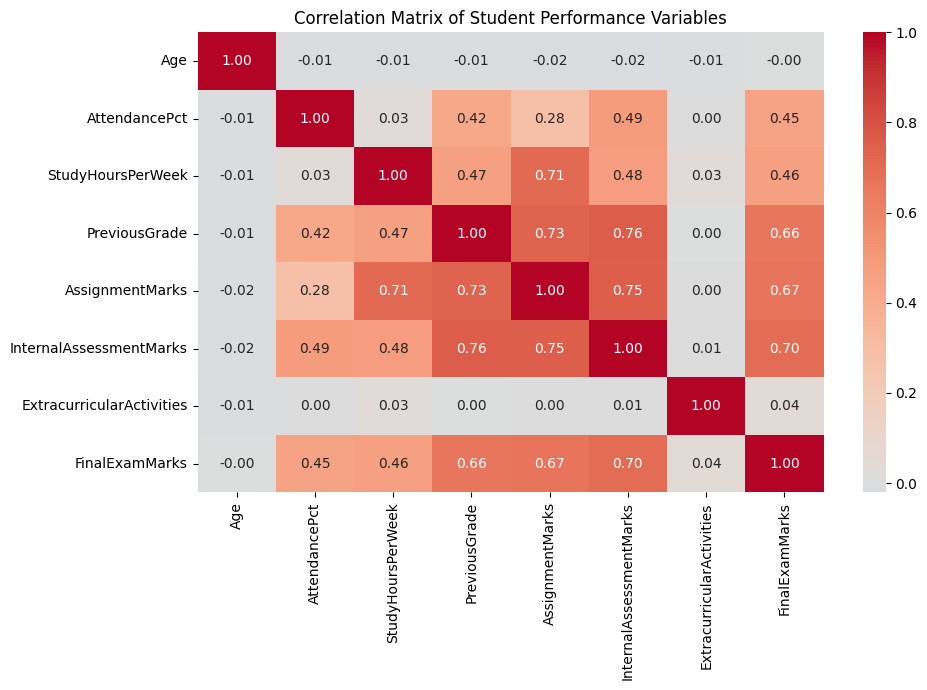

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Student Performance Variables")
plt.tight_layout()
plt.show()

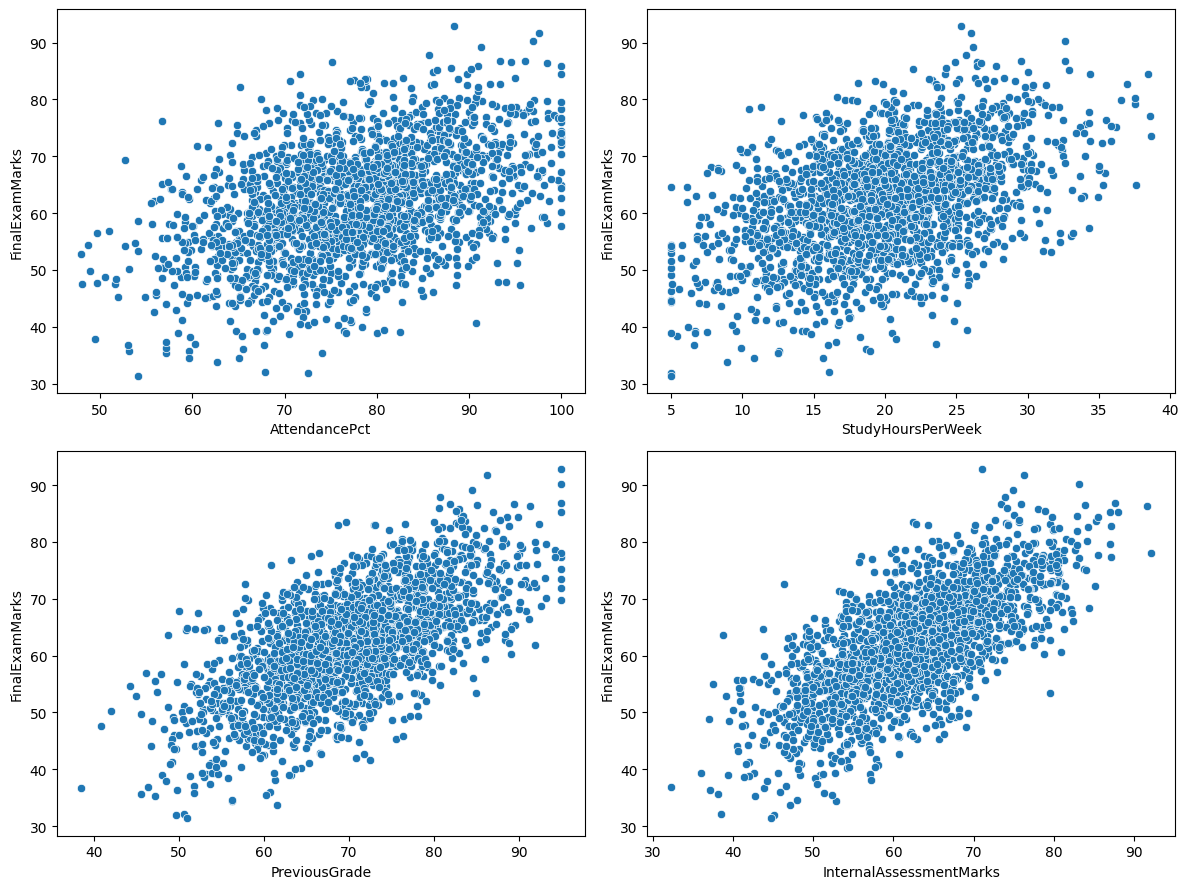

In [19]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

sns.scatterplot(
    data=df,
    x="AttendancePct",
    y="FinalExamMarks",
    ax=axes[0, 0]
)

sns.scatterplot(
    data=df,
    x="StudyHoursPerWeek",
    y="FinalExamMarks",
    ax=axes[0, 1]
)

sns.scatterplot(
    data=df,
    x="PreviousGrade",
    y="FinalExamMarks",
    ax=axes[1, 0]
)

sns.scatterplot(
    data=df,
    x="InternalAssessmentMarks",
    y="FinalExamMarks",
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

# 16. Save Clean Synthetic Dataset

In [20]:
output_path = "/kaggle/working/student_performance_synthetic_clean.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"Dataset saved to: {output_path}")

Dataset saved to: /kaggle/working/student_performance_synthetic_clean.csv
